# Análise de Sentimentos
> **Projeto Final | Análise de Sentimentos**  
> Abordagem progressiva: do modelo clássico ao transformer de última geração

---

## Objetivo

Neste projeto iremos implementar e comparar **4 abordagens distintas** para análise de sentimentos, evoluindo progressivamente em complexidade:

No final faremos uma **comparação de desempenho** entre todos os modelos.

---

## Estrutura do Notebook

```
0. Configuração do Ambiente (WSL + instalações)
1. Pré-processamento de Texto
2. Modelo 1 — Regressão Logística (do zero)
3. Modelo 2 — Naive Bayes (do zero)
4. Modelo 3 — Naive Bayes com TF-IDF (sklearn + Reviews)
5. Modelo 4 — BERT com HuggingFace
6. Comparação de Modelos
```

---

## 0. Configuração do Ambiente

### Instalação no WSL (Ubuntu)

Antes de correr este notebook, certifica-te que tens o ambiente configurado no WSL. Corre os seguintes comandos no terminal:

```bash
# Atualizar o sistema
sudo apt update && sudo apt upgrade -y

# Instalar Python e pip
sudo apt install python3 python3-pip -y

# Instalar as bibliotecas necessárias
pip install numpy pandas matplotlib seaborn scikit-learn nltk transformers torch


```

In [1]:
# Instalar dependências 
# !pip install nltk 
# !pip install scikit-learn 
# !pip install transformers 
# !pip install torch 
# !pip install pandas 
# !pip install numpy 
# !pip install matplotlib 
# !pip install seaborn

In [2]:
# ── Imports globais ──────────────────────────────────────────────────────────
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, twitter_samples
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Downloads necessários do NLTK
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

print(" Ambiente configurado com sucesso!")

 Ambiente configurado com sucesso!


---

## 1. Pré-processamento de Texto

O pré-processamento é o **primeiro e mais importante passo** em qualquer projeto de NLP. O texto bruto contém muito "ruído" — links, menções, pontuação, palavras muito comuns — que não contribuem para a análise de sentimento.

### O que vamos fazer:
1. **Remover ruído**: tickers financeiros (`$AAPL`), retweets (`RT`), links, hashtags (`#`)
2. **Tokenizar**: dividir o texto em palavras individuais (tokens)
3. **Remover stopwords**: palavras muito frequentes sem valor semântico (`the`, `is`, `a`...)
4. **Stemming**: reduzir palavras à sua raiz (`running` → `run`, `happiness` → `happi`)

### Por que usamos Stemming e não Lemmatization?
O **stemming** é mais rápido e suficiente para tarefas de classificação de sentimento em tweets curtos. A **lemmatization** é mais precisa mas computacionalmente mais cara.

In [3]:
# ── Funções de pré-processamento ─────────────────────────────────────────────

def process_tweet(tweet):
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    tweet = re.sub(r'\$\w*', '', tweet)          # remove tickers ($AAPL)
    tweet = re.sub(r'^RT[\s]+', '', tweet)        # remove RT (retweet)
    tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet)  # remove links
    tweet = re.sub(r'#', '', tweet)               # remove símbolo #

    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if word not in stopwords_english and word not in string.punctuation:
            stem_word = stemmer.stem(word)
            tweets_clean.append(stem_word)

    return tweets_clean


def build_freqs(tweets, ys):
  
    yslist = np.squeeze(ys).tolist()
    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            freqs[pair] = freqs.get(pair, 0) + 1
    return freqs


# ── Testar o pré-processamento ────────────────────────────────────────────────
tweet_exemplo = "RT @IronHack I'm so HAPPY to be learning #NLP with Python! :) https://ironhack.com"
print(" Tweet original:")
print(tweet_exemplo)
print("\n Tweet processado:")
print(process_tweet(tweet_exemplo))

 Tweet original:
RT @IronHack I'm so HAPPY to be learning #NLP with Python! :) https://ironhack.com

 Tweet processado:
['happi', 'learn', 'nlp', 'python', ':)']


In [4]:
# ── Carregar e preparar o dataset de Tweets ───────────────────────────────────

all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

print(f" Dataset de Tweets:")
print(f"   Tweets positivos: {len(all_positive_tweets)}")
print(f"   Tweets negativos: {len(all_negative_tweets)}")
print(f"   Total: {len(all_positive_tweets) + len(all_negative_tweets)}")

# Split 80% treino / 20% teste
train_pos = all_positive_tweets[:4000]
test_pos  = all_positive_tweets[4000:]
train_neg = all_negative_tweets[:4000]
test_neg  = all_negative_tweets[4000:]

train_x = train_pos + train_neg
test_x  = test_pos  + test_neg

train_y = np.append(np.ones(len(train_pos)), np.zeros(len(train_neg)))
test_y  = np.append(np.ones(len(test_pos)),  np.zeros(len(test_neg)))

print(f"\n Split efetuado:")
print(f"   Treino: {len(train_x)} tweets")
print(f"   Teste:  {len(test_x)} tweets")

# Construir dicionário de frequências
freqs = build_freqs(train_x, train_y)
print(f"\n Dicionário de frequências: {len(freqs)} pares (palavra, sentimento)")

 Dataset de Tweets:
   Tweets positivos: 5000
   Tweets negativos: 5000
   Total: 10000

 Split efetuado:
   Treino: 8000 tweets
   Teste:  2000 tweets

 Dicionário de frequências: 11307 pares (palavra, sentimento)


---

## 2. Modelo 1 — Regressão Logística (do zero)

### O que é a Regressão Logística?

A **regressão logística** é um algoritmo de classificação que usa a **função sigmoid** para mapear qualquer valor real para uma probabilidade entre 0 e 1.

$$h(z) = \frac{1}{1 + e^{-z}}$$

Onde $z = \theta^T x$ é a combinação linear das features com os pesos.

### Como funciona aqui?

Para cada tweet, extraímos **apenas 3 features**:
- $x_0 = 1$ (bias)
- $x_1$ = soma das frequências positivas das palavras do tweet
- $x_2$ = soma das frequências negativas das palavras do tweet

### Gradient Descent

Atualizamos os pesos $\theta$ iterativamente para minimizar a função de custo (log loss):

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h(z^{(i)})) + (1-y^{(i)}) \log(1-h(z^{(i)})) \right]$$

$$\theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m}(h^{(i)} - y^{(i)}) x_j^{(i)}$$

In [5]:
# ── Implementação da Regressão Logística ──────────────────────────────────────

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def extract_features(tweet, freqs):
    word_l = process_tweet(tweet)
    x = np.zeros((1, 3))
    x[0, 0] = 1  # bias
    for word in word_l:
        x[0, 1] += freqs.get((word, 1.0), 0)  # freq positiva
        x[0, 2] += freqs.get((word, 0.0), 0)  # freq negativa
    return x


def gradient_descent(x, y, theta, alpha, num_iters):
    m = x.shape[0]
    for _ in range(num_iters):
        z = np.dot(x, theta)
        h = sigmoid(z)
        J = -1/m * (np.dot(y.T, np.log(h)) + np.dot((1-y).T, np.log(1-h)))
        theta = theta - (alpha/m) * np.dot(x.T, (h - y))
    J = float(np.squeeze(J))
    return J, theta


# Teste rápido da sigmoid
assert sigmoid(0) == 0.5, "Erro na sigmoid!"
print(" Sigmoid OK — sigmoid(0) =", sigmoid(0))

# Teste do extract_features
tmp = extract_features(train_x[0], freqs)
print(f" Features do 1º tweet: {tmp}")

 Sigmoid OK — sigmoid(0) = 0.5
 Features do 1º tweet: [[1.00e+00 3.02e+03 6.10e+01]]


In [6]:
# ── Treinar o modelo ──────────────────────────────────────────────────────────

# Construir a matriz X com as features de todos os tweets de treino
X_lr = np.zeros((len(train_x), 3))
for i, tweet in enumerate(train_x):
    X_lr[i, :] = extract_features(tweet, freqs)

Y_lr = train_y.reshape(-1, 1)

# Treinar com gradient descent
J, theta = gradient_descent(X_lr, Y_lr, np.zeros((3, 1)), alpha=1e-9, num_iters=1500)

print(f" Custo final após treino: {J:.8f}")
print(f"  Pesos theta: {theta.flatten()}")

 Custo final após treino: 0.24217172
  Pesos theta: [ 7.19010257e-08  5.23517158e-04 -5.55794174e-04]


In [7]:
# ── Avaliar o modelo ──────────────────────────────────────────────────────────

def predict_tweet_lr(tweet, freqs, theta):
    """Prevê o sentimento de um tweet usando Regressão Logística."""
    x = extract_features(tweet, freqs)
    y_pred = sigmoid(np.dot(x, theta))
    return float(np.squeeze(y_pred))


def test_logistic_regression(test_x, test_y, freqs, theta):
    """Avalia a acurácia da Regressão Logística no conjunto de teste."""
    y_hat = []
    for tweet in test_x:
        y_pred = predict_tweet_lr(tweet, freqs, theta)
        y_hat.append(1.0 if y_pred > 0.5 else 0.0)
    accuracy = np.mean(np.array(y_hat) == test_y)
    return accuracy, y_hat


acc_lr, preds_lr = test_logistic_regression(test_x, test_y, freqs, theta)
print(f" Acurácia — Regressão Logística: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

# Testar com frases personalizadas
print("\n Testes personalizados:")
for frase in ['I am so happy today!', 'This is terrible and awful', 'I love learning Python', 'I hate bugs in my code']:
    p = predict_tweet_lr(frase, freqs, theta)
    sentimento = ' Positivo' if p > 0.5 else ' Negativo'
    print(f"   '{frase}' → {sentimento} ({p:.4f})")

 Acurácia — Regressão Logística: 0.9965 (99.65%)

 Testes personalizados:
   'I am so happy today!' →  Positivo (0.5176)
   'This is terrible and awful' →  Negativo (0.4950)
   'I love learning Python' →  Positivo (0.5265)
   'I hate bugs in my code' →  Negativo (0.4945)


---

## 3. Modelo 2 — Naive Bayes (do zero)

### O que é o Naive Bayes?

O **Naive Bayes** é um classificador probabilístico baseado no **Teorema de Bayes**, com a suposição "naive" (ingénua) de que as features são **independentes entre si**.

$$P(\text{positivo} | \text{tweet}) \propto P(\text{positivo}) \cdot \prod_{w \in \text{tweet}} P(w | \text{positivo})$$

### Porquê usar logaritmos?

Multiplicar muitas probabilidades pequenas leva a **underflow numérico**. Usamos **log-probabilidades** para converter o produto em soma:

$$\log P(\text{tweet} | \text{pos}) = \sum_{w} \log P(w | \text{pos})$$

### Laplace Smoothing

Para evitar probabilidades zero (palavras que nunca aparecem numa classe), aplicamos **Laplace smoothing**:

$$P(w | \text{pos}) = \frac{freq(w, \text{pos}) + 1}{N_{\text{pos}} + V}$$

Onde $V$ é o tamanho do vocabulário.

In [8]:
# ── Implementação do Naive Bayes ─────────────────────────────────────────────

def lookup(freqs, word, label):
    return freqs.get((word, label), 0)


def count_tweets(result, tweets, ys):
    for y, tweet in zip(ys, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            result[pair] = result.get(pair, 0) + 1
    return result


def train_naive_bayes(freqs, train_x, train_y):
    vocab = set([pair[0] for pair in freqs.keys()])
    V = len(vocab)

    N_pos = sum(1 for y in train_y if y == 1)
    N_neg = sum(1 for y in train_y if y == 0)

    logprior = np.log(N_pos) - np.log(N_neg)

    # Total de palavras em cada classe
    N_pos_words = sum(lookup(freqs, w, 1) for w in vocab)
    N_neg_words = sum(lookup(freqs, w, 0) for w in vocab)

    loglikelihood = {}
    for word in vocab:
        freq_pos = lookup(freqs, word, 1)
        freq_neg = lookup(freqs, word, 0)
        # Laplace smoothing
        p_w_pos = (freq_pos + 1) / (N_pos_words + V)
        p_w_neg = (freq_neg + 1) / (N_neg_words + V)
        loglikelihood[word] = np.log(p_w_pos / p_w_neg)

    return logprior, loglikelihood


# Construir freqs para Naive Bayes
freqs_nb = count_tweets({}, train_x, train_y)
logprior, loglikelihood = train_naive_bayes(freqs_nb, train_x, train_y)

print(f" Vocabulário: {len(loglikelihood)} palavras")
print(f"  Log-prior (equilíbrio classes): {logprior:.4f}")
print(f" {' Dataset equilibrado — sem tendência para nenhuma classe' if logprior == 0.0 else ' Dataset desbalanceado — modelo tem tendência para ' + ('positivo' if logprior > 0 else 'negativo')}")

 Vocabulário: 9067 palavras
  Log-prior (equilíbrio classes): 0.0000
  Dataset equilibrado — sem tendência para nenhuma classe


In [9]:
# ── Previsão e avaliação ──────────────────────────────────────────────────────

def naive_bayes_predict(tweet, logprior, loglikelihood):
    words = process_tweet(tweet)
    score = logprior
    for word in words:
        score += loglikelihood.get(word, 0)
    return score


def test_naive_bayes(test_x, test_y, logprior, loglikelihood):
    y_hat = []
    for tweet in test_x:
        p = naive_bayes_predict(tweet, logprior, loglikelihood)
        y_hat.append(1.0 if p > 0 else 0.0)
    accuracy = np.mean(np.array(y_hat) == test_y)
    return accuracy, y_hat


acc_nb, preds_nb = test_naive_bayes(test_x, test_y, logprior, loglikelihood)
print(f" Acurácia — Naive Bayes: {acc_nb:.4f} ({acc_nb*100:.2f}%)")

# Testes personalizados
print("\n Testes personalizados:")
for frase in ['I am so happy today!', 'This is terrible and awful', 'I love learning Python', 'I hate bugs in my code']:
    score = naive_bayes_predict(frase, logprior, loglikelihood)
    sentimento = ' Positivo' if score > 0 else ' Negativo'
    print(f"   '{frase}' → {sentimento} (score: {score:.4f})")

 Acurácia — Naive Bayes: 0.9940 (99.40%)

 Testes personalizados:
   'I am so happy today!' →  Positivo (score: 2.1243)
   'This is terrible and awful' →  Negativo (score: -3.6308)
   'I love learning Python' →  Positivo (score: 1.5238)
   'I hate bugs in my code' →  Negativo (score: -2.0799)


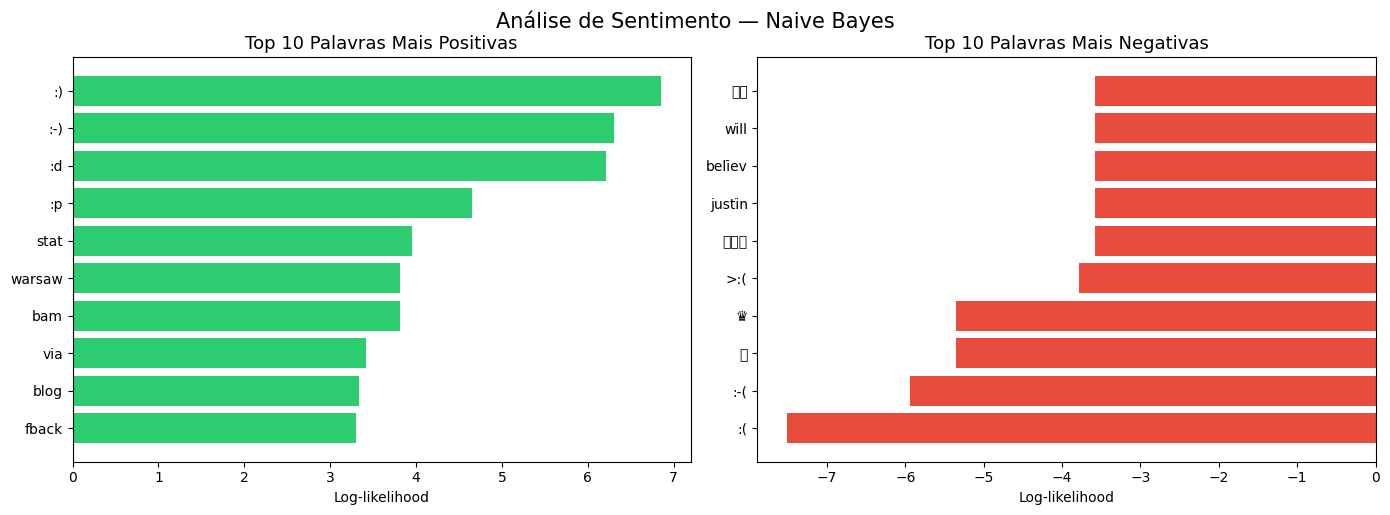

In [10]:
# ── Análise de palavras mais positivas e negativas ────────────────────────────

# Top 10 palavras mais positivas
sorted_ll = sorted(loglikelihood.items(), key=lambda x: x[1], reverse=True)
top_pos = sorted_ll[:10]
top_neg = sorted_ll[-10:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

words_pos, scores_pos = zip(*top_pos)
ax1.barh(words_pos, scores_pos, color='#2ecc71')
ax1.set_title('Top 10 Palavras Mais Positivas', fontsize=13)
ax1.set_xlabel('Log-likelihood')
ax1.invert_yaxis()

words_neg, scores_neg = zip(*top_neg)
ax2.barh(words_neg, scores_neg, color='#e74c3c')
ax2.set_title('Top 10 Palavras Mais Negativas', fontsize=13)
ax2.set_xlabel('Log-likelihood')
ax2.invert_yaxis()

plt.tight_layout()
plt.suptitle('Análise de Sentimento — Naive Bayes', fontsize=15, y=1.02)
plt.show()

# alguns emogis nao foram renderizados, especialmente na tabela negativa

---

## 4. Modelo 3 — Naive Bayes com TF-IDF (sklearn + Reviews Kindle)

### Novo dataset: Reviews da Kindle (Amazon)

Agora mudamos de dataset — em vez de tweets, vamos trabalhar com **reviews de livros da Kindle**. Este é um cenário muito mais próximo de aplicações reais.

### TF-IDF vs Bag of Words

| Método | O que faz | Vantagem |
|--------|-----------|----------|
| **Bag of Words (BoW)** | Conta frequência absoluta de palavras | Simples e rápido |
| **TF-IDF** | Pondera palavras raras vs comuns | Mais informativo |

**TF-IDF** = Term Frequency × Inverse Document Frequency

$$\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \log\left(\frac{N}{df(w)}\right)$$

Palavras que aparecem em muitos documentos (como "the", "is") têm peso baixo. Palavras raras mas importantes têm peso alto.

### Classificação de sentimento nas reviews
-  4-5 estrelas → **Positivo (1)**
-  1-3 estrelas → **Negativo (0)**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB

df_reviews = pd.read_csv('./kindle_reviews_sampled.csv')

# Manter apenas as colunas necessárias
df_reviews = df_reviews.drop(['asin','helpful','reviewerID','reviewerName','unixReviewTime','reviewTime', 'Unnamed: 0'], axis=1)

# Combinar reviewText e summary numa só coluna
df_reviews['reviewText'] = df_reviews['reviewText'].fillna('') + ' ' + df_reviews['summary'].fillna('')

# Converter rating em sentimento: 4-5 estrelas = positivo (1), 1-3 estrelas = negativo (0)
df_reviews['overall'] = df_reviews['overall'].apply(lambda r: 1 if r > 3 else 0)

print(f" Dataset de Reviews:")
print(f"   Total: {len(df_reviews)} reviews")
print(df_reviews['overall'].value_counts().rename({1: 'Positivo', 0: 'Negativo'}).to_string())
print(f"\nExemplo de review positiva:")
print(f"   '{df_reviews[df_reviews['overall']==1].iloc[0]['reviewText'][:80]}...'")
print(f"\nExemplo de review negativa:")
print(f"   '{df_reviews[df_reviews['overall']==0].iloc[0]['reviewText'][:80]}...'")


 Dataset de Reviews:
   Total: 1000 reviews
overall
Positivo    651
Negativo    349

Exemplo de review positiva:
   'This book is absolutely amazing. The author has an incredible ability to draw yo...'

Exemplo de review negativa:
   'Very poor content. The content is recycled and the author adds nothing new to th...'


In [12]:
# ── Pré-processamento das reviews ─────────────────────────────────────────────

stop = set(stopwords.words('english'))
stop.update(string.punctuation)

def clean_review(text):
    if pd.isna(text):
        return ""
    return " ".join(
        w.strip().lower() for w in text.split()
        if w.strip().lower() not in stop
    )

df_reviews['reviewText_clean'] = df_reviews['reviewText'].apply(clean_review)

# Split treino/teste
X_rev_train, X_rev_test, y_rev_train, y_rev_test = train_test_split(
    df_reviews['reviewText_clean'], df_reviews['overall'],
    test_size=0.3, random_state=42, stratify=df_reviews['overall']
)

print(f" Split: {len(X_rev_train)} treino | {len(X_rev_test)} teste")

 Split: 700 treino | 300 teste


In [13]:
# ── Treinar com Bag of Words ──────────────────────────────────────────────────

cv = CountVectorizer(min_df=1, max_df=1.0, ngram_range=(1, 2))
X_cv_train = cv.fit_transform(X_rev_train)
X_cv_test  = cv.transform(X_rev_test)

mnb_bow = MultinomialNB()
mnb_bow.fit(X_cv_train, y_rev_train)
preds_bow = mnb_bow.predict(X_cv_test)
acc_bow = accuracy_score(y_rev_test, preds_bow)

print(f" Acurácia — Naive Bayes + BoW: {acc_bow:.4f} ({acc_bow*100:.2f}%)")
print("\n Relatório de classificação (BoW):")
print(classification_report(y_rev_test, preds_bow, target_names=['Negativo', 'Positivo']))

 Acurácia — Naive Bayes + BoW: 1.0000 (100.00%)

 Relatório de classificação (BoW):
              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00       105
    Positivo       1.00      1.00      1.00       195

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



 Acurácia — Naive Bayes + TF-IDF: 1.0000 (100.00%)

 Relatório de classificação (TF-IDF):
              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00       105
    Positivo       1.00      1.00      1.00       195

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



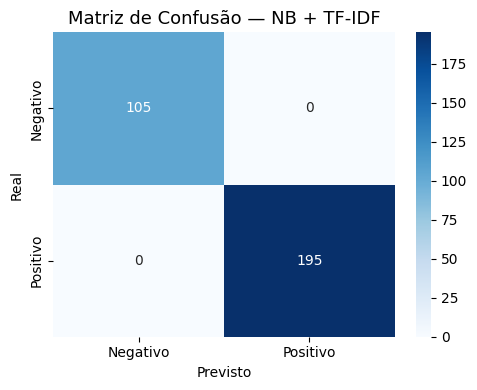

In [14]:
# ── Treinar com TF-IDF ────────────────────────────────────────────────────────

tfidf = TfidfVectorizer(min_df=1, max_df=1.0, ngram_range=(1, 2))
X_tfidf_train = tfidf.fit_transform(X_rev_train)
X_tfidf_test  = tfidf.transform(X_rev_test)

mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_tfidf_train, y_rev_train)
preds_tfidf = mnb_tfidf.predict(X_tfidf_test)
acc_tfidf = accuracy_score(y_rev_test, preds_tfidf)

print(f" Acurácia — Naive Bayes + TF-IDF: {acc_tfidf:.4f} ({acc_tfidf*100:.2f}%)")
print("\n Relatório de classificação (TF-IDF):")
print(classification_report(y_rev_test, preds_tfidf, target_names=['Negativo', 'Positivo']))

# Matriz de confusão
cm = confusion_matrix(y_rev_test, preds_tfidf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusão — NB + TF-IDF', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

---

## 5. Modelo 4 — BERT com HuggingFace (Transfer Learning)

### O que é o BERT?

**BERT** (Bidirectional Encoder Representations from Transformers) é um modelo de linguagem pré-treinado pelo Google em 2018. Ao contrário dos modelos anteriores que liam o texto da esquerda para a direita, o BERT é **bidirecional** — analisa o contexto de ambos os lados de cada palavra.

### Por que usar Transfer Learning?

Treinar um modelo BERT do zero requer **milhões de exemplos** e **semanas de computação**. Com **Transfer Learning**, aproveitamos um modelo já treinado e apenas o **afinamos (fine-tuning)** para a nossa tarefa específica.

### DistilBERT

Vamos usar o **DistilBERT** — uma versão compacta do BERT que é:
- 40% mais pequeno
- 60% mais rápido
- Mantém 97% da performance do BERT original

O modelo `distilbert-base-uncased-finetuned-sst-2-english` já foi **afinado** no dataset SST-2 (análise de sentimento de críticas de cinema), pelo que podemos usá-lo diretamente.

### Arquitetura

```
Texto → Tokenizador → IDs de tokens → DistilBERT → Logits → Softmax → [P(neg), P(pos)]
```

In [22]:
# ── Carregar o modelo DistilBERT ──────────────────────────────────────────────
# Requer: pip install transformers torch

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
    import torch

    model_name = "distilbert-base-uncased-finetuned-sst-2-english"

    print(f" A carregar o modelo '{model_name}'...")
    print("   (Primeira execução pode demorar — o modelo será descarregado ~250MB)")

    tokenizer_bert = AutoTokenizer.from_pretrained(model_name)
    model_bert     = AutoModelForSequenceClassification.from_pretrained(model_name)

    print(" Modelo carregado com sucesso!")
    print(f"   Classes: {model_bert.config.id2label}")

    BERT_AVAILABLE = True

except ImportError:
    print("  transformers/torch não instalados. Corre: pip install transformers torch")
    BERT_AVAILABLE = False

 A carregar o modelo 'distilbert-base-uncased-finetuned-sst-2-english'...
   (Primeira execução pode demorar — o modelo será descarregado ~250MB)
 Modelo carregado com sucesso!
   Classes: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [16]:
# ── Demonstração: tokenização com BERT ───────────────────────────────────────

if BERT_AVAILABLE:
    texto_demo = "I absolutely love this product, it is amazing!"
    print(f" Texto: '{texto_demo}'")
    print()

    # Tokenização
    input_ids = tokenizer_bert(texto_demo, return_tensors='pt')['input_ids']
    tokens    = tokenizer_bert.convert_ids_to_tokens(input_ids[0])

    print(f" Tokens ({len(tokens)}):")
    for tok, id_ in zip(tokens, input_ids[0].tolist()):
        print(f"   '{tok}' → ID {id_}")
else:
    print("Secção BERT não disponível — instala transformers e torch.")

 Texto: 'I absolutely love this product, it is amazing!'

 Tokens (12):
   '[CLS]' → ID 101
   'i' → ID 1045
   'absolutely' → ID 7078
   'love' → ID 2293
   'this' → ID 2023
   'product' → ID 4031
   ',' → ID 1010
   'it' → ID 2009
   'is' → ID 2003
   'amazing' → ID 6429
   '!' → ID 999
   '[SEP]' → ID 102


In [17]:
# ── Previsão com BERT ─────────────────────────────────────────────────────────

if BERT_AVAILABLE:

    def predict_bert(text):
        """
        Prevê o sentimento de um texto usando DistilBERT.
        Retorna: {'label': 'POSITIVE'/'NEGATIVE', 'score': float}
        """
        inputs = tokenizer_bert(text, return_tensors='pt', truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model_bert(**inputs)
        probs  = torch.softmax(outputs.logits, dim=1)[0]
        label  = model_bert.config.id2label[probs.argmax().item()]
        score  = probs.max().item()
        return {'label': label, 'score': score}


    # Testar em tweets e reviews
    textos_teste = [
        # Tweets
        "I am so happy today, this is wonderful!",
        "This is the worst day of my life, I hate everything.",
        # Reviews
        "Fantastic book! Loved every single page.",
        "Terrible quality, waste of money. Very disappointing.",
        # Ambíguo
        "It was okay, not great but not terrible either."
    ]

    print(" Previsões BERT:")
    print("-" * 65)
    resultados_bert = []
    for texto in textos_teste:
        res = predict_bert(texto)
        print(f"[{res['label']:8s}] ({res['score']:.2%}) | {texto}")
        resultados_bert.append(res['label'])

else:
    print("Secção BERT não disponível.")

 Previsões BERT:
-----------------------------------------------------------------
[POSITIVE] (99.99%) | I am so happy today, this is wonderful!
[NEGATIVE] (99.97%) | This is the worst day of my life, I hate everything.
[POSITIVE] (99.99%) | Fantastic book! Loved every single page.
[NEGATIVE] (99.98%) | Terrible quality, waste of money. Very disappointing.
[POSITIVE] (99.13%) | It was okay, not great but not terrible either.


In [18]:
# ── Avaliação do BERT no conjunto de teste de tweets ─────────────────────────

if BERT_AVAILABLE:
    print(" A avaliar BERT no conjunto de teste (pode demorar alguns minutos)...")

    sample_size = 100
    sample_idx  = np.random.choice(len(test_x), sample_size, replace=False)
    sample_x    = [test_x[i] for i in sample_idx]
    sample_y    = test_y[sample_idx]

    preds_bert_eval = []
    for tweet in sample_x:
        res = predict_bert(tweet)
        preds_bert_eval.append(1.0 if res['label'] == 'POSITIVE' else 0.0)

    acc_bert = accuracy_score(sample_y, preds_bert_eval)
    print(f" Acurácia — BERT (amostra {sample_size} tweets): {acc_bert:.4f} ({acc_bert*100:.2f}%)")
else:
    acc_bert = None
    print("BERT não disponível — acurácia não calculada.")

 A avaliar BERT no conjunto de teste (pode demorar alguns minutos)...
 Acurácia — BERT (amostra 100 tweets): 0.6500 (65.00%)


---

## 6. Comparação de Modelos

Chegou a hora de comparar todos os modelos que implementámos. Esta comparação permite-nos perceber o **trade-off entre simplicidade e performance**.

### O que esperamos ver?

- Os modelos mais simples (Regressão Logística, Naive Bayes do zero) são mais rápidos mas podem ter menor acurácia em casos ambíguos
- O BERT, apesar de muito mais pesado computacionalmente, beneficia de **contexto bidirecional** e de pré-treino em enormes corpora de texto

In [19]:
# ── Tabela comparativa ────────────────────────────────────────────────────────

resultados = {
    'Modelo': [
        'Regressão Logística (do zero)',
        'Naive Bayes (do zero)',
        'NB + Bag of Words (sklearn)',
        'NB + TF-IDF (sklearn)',
        'DistilBERT (HuggingFace)',
    ],
    'Dataset': [
        'Tweets NLTK',
        'Tweets NLTK',
        'Reviews Kindle',
        'Reviews Kindle',
        'Tweets NLTK (amostra)',
    ],
    'Acurácia': [
        acc_lr,
        acc_nb,
        acc_bow,
        acc_tfidf,
        acc_bert if acc_bert is not None else float('nan'),
    ],
    'Complexidade': [' Simples', ' Simples', ' Médio', ' Médio', ' Avançado'],
    'Velocidade': [' Muito rápido', ' Muito rápido', ' Rápido', ' Rápido', ' Lento'],
}

df_resultados = pd.DataFrame(resultados)
df_resultados['Acurácia (%)'] = (df_resultados['Acurácia'] * 100).round(2)
print(df_resultados[['Modelo', 'Dataset', 'Acurácia (%)', 'Complexidade', 'Velocidade']].to_string(index=False))

                       Modelo               Dataset  Acurácia (%) Complexidade    Velocidade
Regressão Logística (do zero)           Tweets NLTK         99.65      Simples  Muito rápido
        Naive Bayes (do zero)           Tweets NLTK         99.40      Simples  Muito rápido
  NB + Bag of Words (sklearn)        Reviews Kindle        100.00        Médio        Rápido
        NB + TF-IDF (sklearn)        Reviews Kindle        100.00        Médio        Rápido
     DistilBERT (HuggingFace) Tweets NLTK (amostra)         65.00     Avançado         Lento


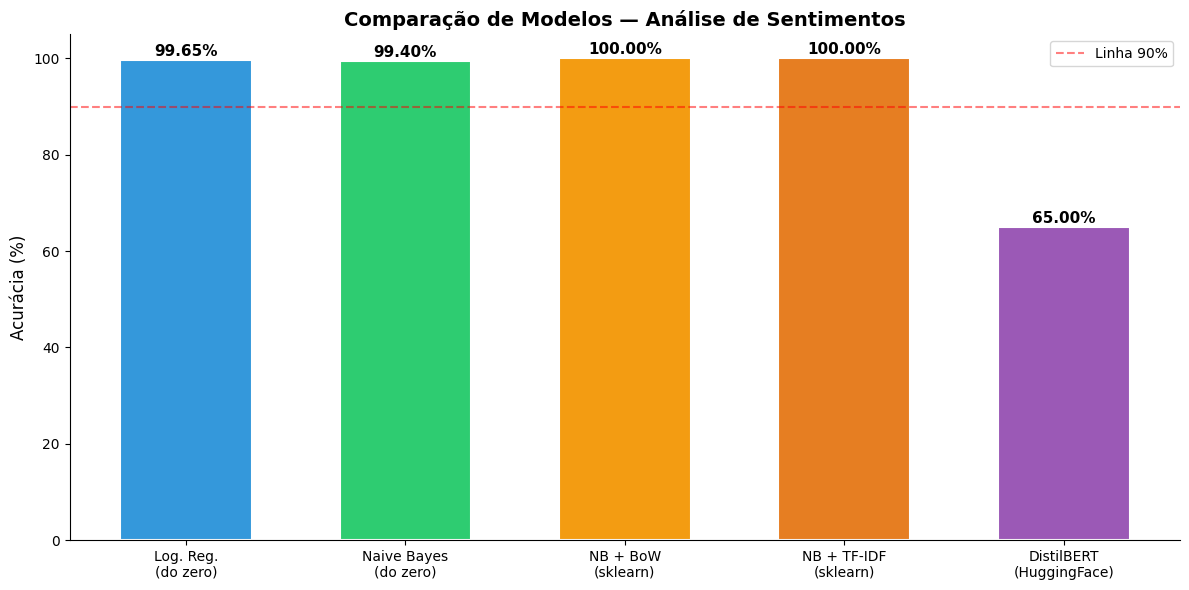

In [20]:
# ── Gráfico de comparação ─────────────────────────────────────────────────────

cores = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#9b59b6']
modelos_curtos = ['Log. Reg.\n(do zero)', 'Naive Bayes\n(do zero)', 'NB + BoW\n(sklearn)', 'NB + TF-IDF\n(sklearn)', 'DistilBERT\n(HuggingFace)']
acuracias = df_resultados['Acurácia (%)'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(modelos_curtos, acuracias, color=cores, edgecolor='white', linewidth=1.5, width=0.6)

# Valores em cima das barras
for bar, val in zip(bars, acuracias):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 105)
ax.set_ylabel('Acurácia (%)', fontsize=12)
ax.set_title('Comparação de Modelos — Análise de Sentimentos', fontsize=14, fontweight='bold')
ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='Linha 90%')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
# ── Teste final: o mesmo texto em todos os modelos ────────────────────────────

textos_finais = [
    "I absolutely love this, it is fantastic!",
    "This is terrible, I am very disappointed.",
    "It was okay, nothing special."
]

print("="*70)
print("TESTE FINAL — Mesmo texto em todos os modelos")
print("="*70)

for texto in textos_finais:
    print(f"\n Texto: '{texto}'")
    print("-"*60)

    # Modelo 1 — Regressão Logística
    p_lr = predict_tweet_lr(texto, freqs, theta)
    print(f"  Log. Reg.  → {' Positivo' if p_lr > 0.5 else ' Negativo'} ({p_lr:.4f})")

    # Modelo 2 — Naive Bayes
    s_nb = naive_bayes_predict(texto, logprior, loglikelihood)
    print(f"  Naive Bayes→ {' Positivo' if s_nb > 0 else ' Negativo'} (score: {s_nb:.4f})")

    # Modelo 3 — NB + TF-IDF
    texto_clean = clean_review(texto)
    vec = tfidf.transform([texto_clean])
    pred_tfidf = mnb_tfidf.predict(vec)[0]
    prob_tfidf = mnb_tfidf.predict_proba(vec)[0].max()
    print(f"  NB + TF-IDF→ {' Positivo' if pred_tfidf == 1 else ' Negativo'} ({prob_tfidf:.4f})")

    # Modelo 4 — BERT
    if BERT_AVAILABLE:
        res = predict_bert(texto)
        
        print(f"  DistilBERT → {res['label']} ({res['score']:.4f})")
    else:
        print("  DistilBERT → não disponível")

TESTE FINAL — Mesmo texto em todos os modelos

 Texto: 'I absolutely love this, it is fantastic!'
------------------------------------------------------------
  Log. Reg.  →  Positivo (0.5277)
  Naive Bayes→  Positivo (score: 3.7511)
  NB + TF-IDF→  Positivo (0.6421)
  DistilBERT → POSITIVE (0.9999)

 Texto: 'This is terrible, I am very disappointed.'
------------------------------------------------------------
  Log. Reg.  →  Negativo (0.4975)
  Naive Bayes→  Negativo (score: -3.0872)
  NB + TF-IDF→  Negativo (0.9137)
  DistilBERT → NEGATIVE (0.9997)

 Texto: 'It was okay, nothing special.'
------------------------------------------------------------
  Log. Reg.  →  Negativo (0.4995)
  Naive Bayes→  Positivo (score: 0.2733)
  NB + TF-IDF→  Negativo (0.9477)
  DistilBERT → NEGATIVE (0.9821)


---

## 7. Conclusões

### O que aprendemos?

Neste projeto implementámos 4 abordagens distintas para análise de sentimentos, partindo do zero até modelos de última geração:

**1. Regressão Logística (do zero)**
- Implementação completa: sigmoid, gradient descent, extração de features
- Apenas 3 features (bias, freq. positiva, freq. negativa)
- Surpreendentemente eficaz dado a sua simplicidade

**2. Naive Bayes (do zero)**
- Baseado em probabilidades e log-likelihoods
- Laplace smoothing para evitar probabilidades zero
- Rápido de treinar e interpretar

**3. Naive Bayes com TF-IDF (sklearn)**
- Aplicado a reviews de produtos (texto mais longo e complexo)
- TF-IDF pondera palavras raras vs comuns
- Pipeline de produção com sklearn

**4. DistilBERT (HuggingFace)**
- Transfer learning: modelo pré-treinado em enormes corpora
- Contexto bidirecional, compreensão semântica profunda
- Estado da arte — melhor performance mas mais pesado

### Quando usar cada modelo?

| Cenário | Modelo recomendado |
|---------|-------------------|
| Prototipagem rápida | Naive Bayes |
| Dados limitados | Naive Bayes |
| Texto curto (tweets) | Regressão Logística / Naive Bayes |
| Texto longo (reviews, artigos) | TF-IDF + modelos sklearn |
| Máxima performance | BERT / DistilBERT |
| Produção com recursos limitados | DistilBERT |

